### Advance Agent flow with Langchain

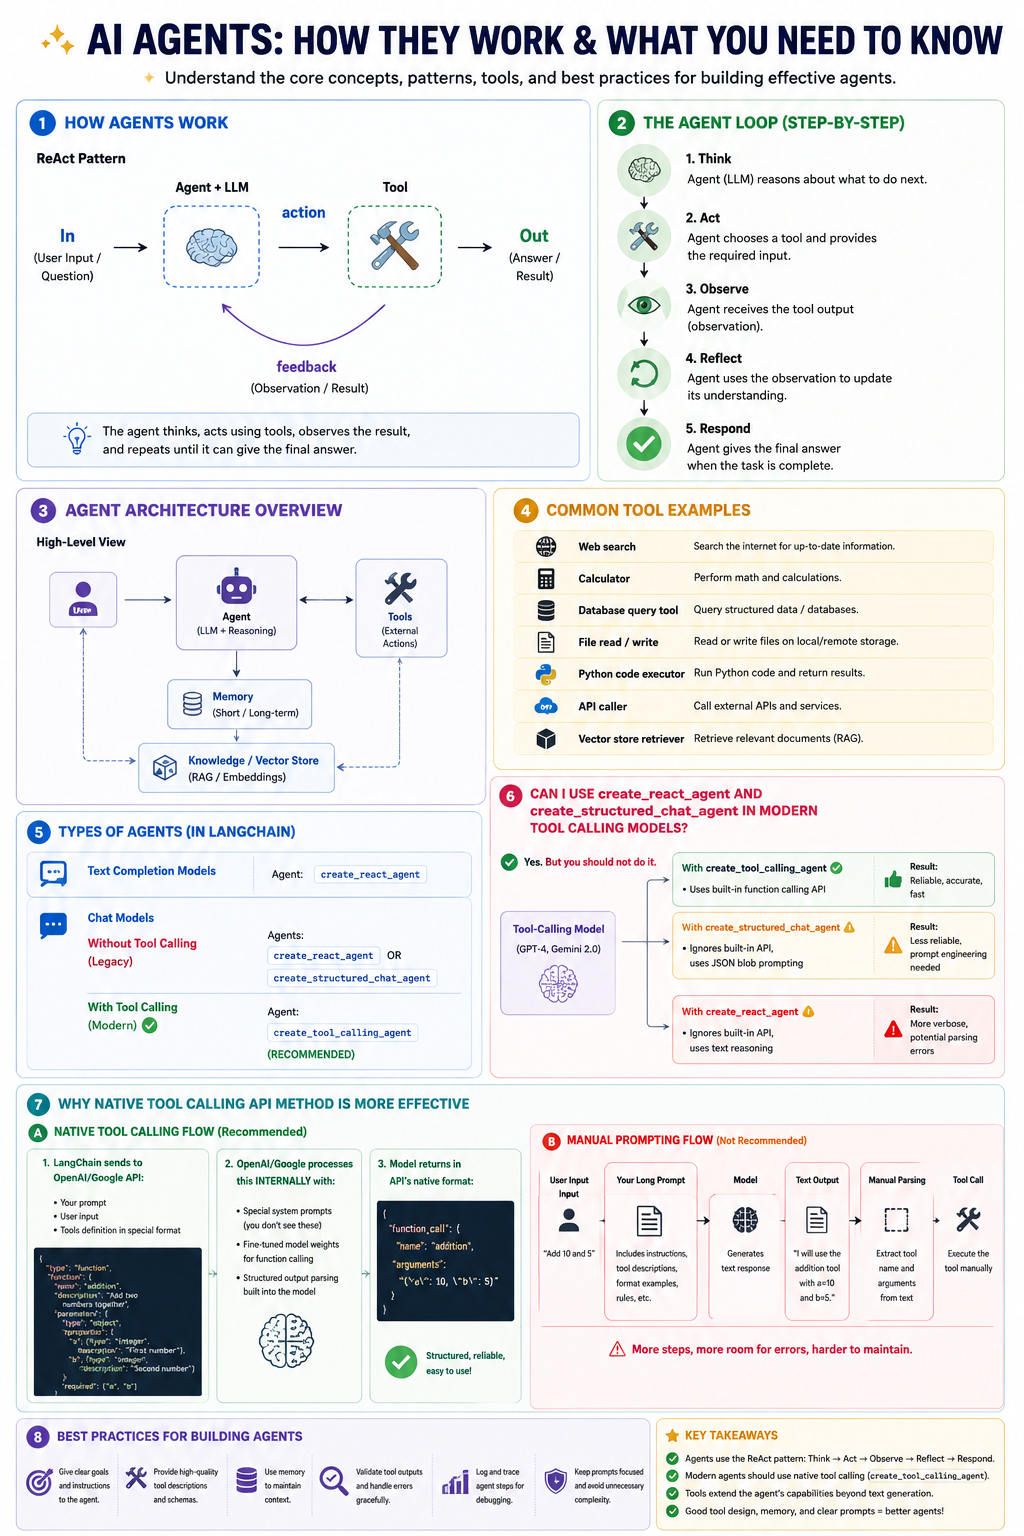

In [2]:
import langchain 
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate , ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

load_dotenv()
Groq_api_key=os.getenv("GROQ_API_KEY")

llm=ChatGroq(
    api_key=Groq_api_key,
    model="openai/gpt-oss-120b",
    temperature=0.2
    )



## Flow  for this Agent

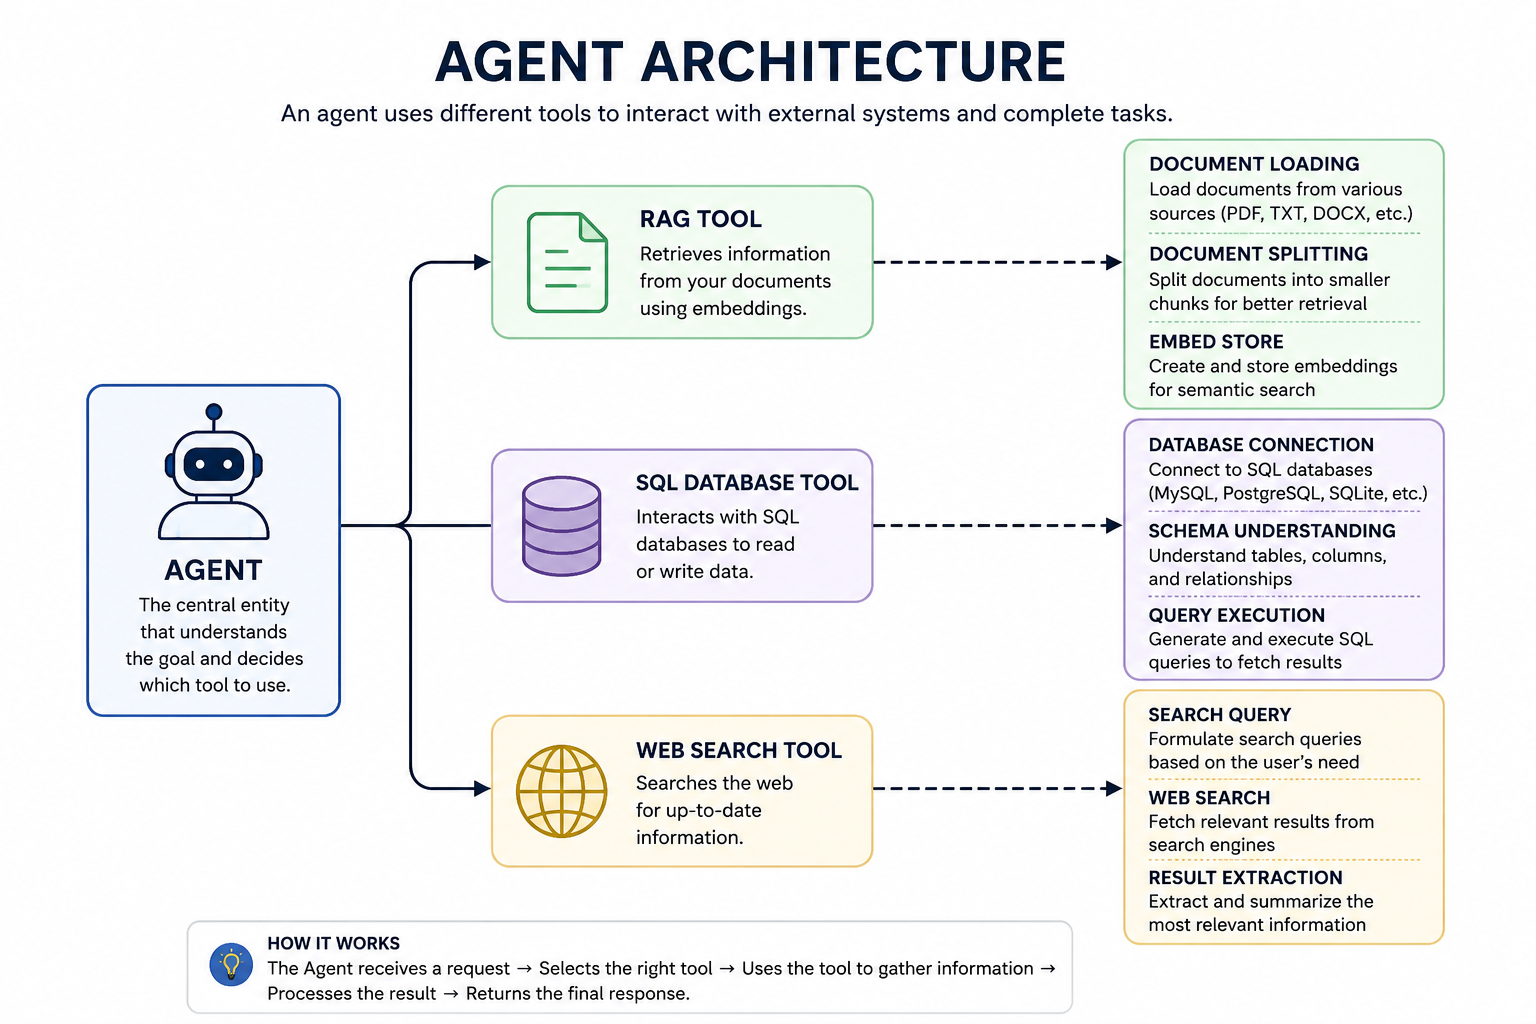

In [1]:
from langchain_classic.agents import tools
from langchain_community.document_loaders import TextLoader
from langchain_community.document_loaders import  PyPDFLoader

pdf_loader=PyPDFLoader("./Additional files/Rag_pdf_content.pdf")
text_loader=TextLoader("./Additional files/10_vijay_Small_RAG_Content.txt",encoding="utf8")
pdf=pdf_loader.load()
text=text_loader.load()

all_docs=pdf+text

print(len(pdf))
print(len(text))
print(len(all_docs))

21
1
22


In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter 

text_splitter=RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=50)

split_docs=text_splitter.split_documents(all_docs)
len(split_docs)

153

In [4]:
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

embeddings=HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectorstore=Chroma.from_documents(split_docs,embeddings,persist_directory="./chroma_db")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [5]:
result =await vectorstore.asimilarity_search("Who is TVK president?")
result[0].page_content

'In February 2024, Vijay announced his retirement from cinema and formal entry into politics. He launched TVK as a secular and egalitarian alternative to the established Dravidian parties. TVK secured 108 seats in the 2026 Tamil Nadu Legislative Assembly election, becoming the single-largest party and breaking the half-century-long bureaucratic duopoly of the DMK and the AIADMK.[2][3] With support from several smaller allied parties, Vijay was sworn in as chief minister on 10 May 2026.\n\nEARLY LIFE\nChandrasekaran Joseph Vijay was born on 22 June 1974 in Madras.[4][5] His father, Chandrasekaran, is a film director; his mother, Shoba, is a playback singer and vocalist.[6] His father is a lapsed Catholic and his mother is an adherent of Hinduism.[7][8] Vijay had a sister, Vidhya, who died when she was two years old.[9]'

#### change this vectorstore to runnable 

In [6]:
retriever =vectorstore.as_retriever()
result=retriever.invoke("Who is TVK president?")
print(result[0].page_content)

In February 2024, Vijay announced his retirement from cinema and formal entry into politics. He launched TVK as a secular and egalitarian alternative to the established Dravidian parties. TVK secured 108 seats in the 2026 Tamil Nadu Legislative Assembly election, becoming the single-largest party and breaking the half-century-long bureaucratic duopoly of the DMK and the AIADMK.[2][3] With support from several smaller allied parties, Vijay was sworn in as chief minister on 10 May 2026.

EARLY LIFE
Chandrasekaran Joseph Vijay was born on 22 June 1974 in Madras.[4][5] His father, Chandrasekaran, is a film director; his mother, Shoba, is a playback singer and vocalist.[6] His father is a lapsed Catholic and his mother is an adherent of Hinduism.[7][8] Vijay had a sister, Vidhya, who died when she was two years old.[9]


#### Creating Rag 

In [7]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant"),
    ("human", """Always answer the question just by using the context provided and not from your knowledge.
    Context: {context}
    question: {input}
    
    Answer:"""),
    ("placeholder", "{agent_scratchpad}")
])

chain = {"context": retriever, "input": RunnablePassthrough()} | prompt | llm | StrOutputParser()

# chain = {"context": RunnableLambda(lambda x: x["input"]) | retriever, "input": RunnableLambda(lambda x: x["input"])} | prompt

res = chain.invoke("Write a tag line for vijay with in 10 words?")

print(res)


Vijay: Heroic, philanthropic, fighting injustice for Tamil Nadu.


### Changing this RAG to tool

##### doc string is very very important , without doc string agent cant what about this tool

In [10]:
from langchain.tools import tool
@tool
def Rag_tool(query: str) -> str:
    """you are a helpful assistant that can answer questions based on vectorstore data. Always answer the question just by using the context provided and not from your knowledge."""

    retriever =vectorstore.as_retriever()


    from langchain_core.prompts import ChatPromptTemplate
    from langchain_core.runnables import RunnablePassthrough, RunnableLambda
    from langchain_core.output_parsers import StrOutputParser

    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a helpful assistant"),
        ("human", """Always answer the question just by using the context provided and not from your knowledge.
        Context: {context}
        question: {input}
        
        Answer:"""),
        ("placeholder", "{agent_scratchpad}")
    ])

    chain = {"context": retriever, "input": RunnablePassthrough()} | prompt | llm | StrOutputParser()

    # chain = {"context": RunnableLambda(lambda x: x["input"]) | retriever, "input": RunnableLambda(lambda x: x["input"])} | prompt

    rag_result = chain.invoke("Write a tag line for vijay with in 10 words?")

    return rag_result


###  Tool Creation — Database Agent using create_sql_agent   -> just understand how it works , i am not adding this to my flow now

In [9]:
'''
import os
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import create_sql_agent
from langchain.tools import tool

db_url = os.getenv('DATABASE_URL')

db = SQLDatabase.from_uri(db_url)  # db.run("SELECT * FROM users;")

agent_executor = create_sql_agent(
    db=db,
    llm=google_llm,
    verbose=True
)


@tool
def search_database(input: str) -> str:
    """Search the users database to answer queries about user information.

    Use this tool when you need to find information about users such as:
    - User details (username, name, email, date of birth)
    - User account status (is_active)
    - User creation dates

    Examples of queries this tool can handle:
    - "What is the email of John Doe?"
    - "Find all active users"
    - "When was Alice's account created?"
    - "List all usernames in the database"

    Args:
        input: Natural language query about users

    Returns:
        str: Answer to the query based on the database
    """
    res = agent_executor.invoke({"input": input})
    return res["output"]


# search_database.invoke({"input": "what is the email of the username praveen12?"})

'''

'\nimport os\nfrom langchain_community.utilities import SQLDatabase\nfrom langchain_community.agent_toolkits import create_sql_agent\nfrom langchain.tools import tool\n\ndb_url = os.getenv(\'DATABASE_URL\')\n\ndb = SQLDatabase.from_uri(db_url)  # db.run("SELECT * FROM users;")\n\nagent_executor = create_sql_agent(\n    db=db,\n    llm=google_llm,\n    verbose=True\n)\n\n\n@tool\ndef search_database(input: str) -> str:\n    """Search the users database to answer queries about user information.\n\n    Use this tool when you need to find information about users such as:\n    - User details (username, name, email, date of birth)\n    - User account status (is_active)\n    - User creation dates\n\n    Examples of queries this tool can handle:\n    - "What is the email of John Doe?"\n    - "Find all active users"\n    - "When was Alice\'s account created?"\n    - "List all usernames in the database"\n\n    Args:\n        input: Natural language query about users\n\n    Returns:\n        str:

### Web search tool creation

In [10]:
'''
from langchain.tools import tool
from langchain_community.utilities import SerpAPIWrapper
load_dotenv() 

serp = SerpAPIWrapper()


@tool
def web_search(input: str) -> str:
    """
    Perform a web search using SerpAPI to find current information.

    Use this tool when you need to:
    - Find current/recent information not in your knowledge base
    - Look up real-time data, news, or events
    - Search for information about people, places, or topics
    - Get up-to-date facts and statistics

    Args:
        query: The search query string

    Returns:
        str: Search results from the web
    """
    return serp.run(input)


# result = web_search.invoke("Who is MS Dhoni?")
# result

'''

'\nfrom langchain.tools import tool\nfrom langchain_community.utilities import SerpAPIWrapper\nload_dotenv() \n\nserp = SerpAPIWrapper()\n\n\n@tool\ndef web_search(input: str) -> str:\n    """\n    Perform a web search using SerpAPI to find current information.\n\n    Use this tool when you need to:\n    - Find current/recent information not in your knowledge base\n    - Look up real-time data, news, or events\n    - Search for information about people, places, or topics\n    - Get up-to-date facts and statistics\n\n    Args:\n        query: The search query string\n\n    Returns:\n        str: Search results from the web\n    """\n    return serp.run(input)\n\n\n# result = web_search.invoke("Who is MS Dhoni?")\n# result\n\n'

In [8]:
from langchain.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun


search = DuckDuckGoSearchRun()


@tool
def web_search(input: str) -> str:
    """
    Perform a web search using DuckDuckGo to find current information.

    Use this tool when you need to:
    - Find current/recent information not in your knowledge base
    - Look up recent information, news, or events
    - Search for information about people, places, or topics
    - Get up-to-date facts and statistics

    Args:
        input: The search query string

    Returns:
        str: Search results from the web
    """
    return search.invoke(input)


# Test the tool
# result = web_search.invoke("When was the Smart India Hackathon 2026 statement released?")
# print(result)

### Execution — Agents & Available Tools

In [17]:
from langchain_classic.agents import create_tool_calling_agent ,AgentExecutor
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser


tools = [
    Rag_tool,
    # search_database,
    web_search
]


prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant."),
    ("human", "{input}"),
    ("placeholder", "{agent_scratchpad}")
])


agent = create_tool_calling_agent(
    llm,
    tools,
    prompt
)


main_agent_executor = AgentExecutor(
    agent=agent,
    tools=tools,
    verbose=True
)


res = main_agent_executor.invoke({
    "input": "who is TVK president and who won the last match between india and pakistan?"
})


res



> Entering new AgentExecutor chain...

Invoking: `Rag_tool` with `{'query': 'TVK president'}`


Vijay: Champion of justice, philanthropy, and blockbuster brilliance.
Invoking: `Rag_tool` with `{'query': 'last match between India and Pakistan winner'}`


Vijay: Angry hero fighting injustice, philanthropic champion.Based on the information available in the provided context:

- **TVK president:** The context identifies **Vijay** as the president (or a leading figure) of TVK.  
- **Last India‑Pakistan match:** The supplied material does not contain any details about the outcome of the most recent cricket match between India and Pakistan, so I can’t provide a winner from this source.

> Finished chain.


{'input': 'who is TVK president and who won the last match between india and pakistan?',
 'output': 'Based on the information available in the provided context:\n\n- **TVK president:** The context identifies **Vijay** as the president (or a leading figure) of TVK.  \n- **Last India‑Pakistan match:** The supplied material does not contain any details about the outcome of the most recent cricket match between India and Pakistan, so I can’t provide a winner from this source.'}

### Database Agent — Using SQLDatabaseToolkit

In [18]:

'''
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.agents import create_tool_calling_agent, AgentExecutor


toolkit = SQLDatabaseToolkit(
    db=db,
    llm=google_llm
)


tools = toolkit.get_tools()

context = toolkit.get_context()

# print(tools, "\n\n\n", context)


# Create custom prompt
messages = [
    (
        "system",
        """You are a helpful SQL assistant.
        Answer questions about the database.

        Available tables: {table_names}
        Database Schema: {table_info}

        """
    ),
    ("user", "{input}"),
    ("placeholder", "{agent_scratchpad}"),
]


prompt = ChatPromptTemplate.from_messages(messages)

prompt = prompt.partial(**context)


agent = create_tool_calling_agent(
    google_llm,
    tools,
    prompt
)


agent_executor = AgentExecutor(
    agent=agent,
    tools=tools,
    verbose=True
)


res = agent_executor.invoke({
    "input": "What is the email of samantha lee"
})


res


'''

'\nfrom langchain_community.agent_toolkits import SQLDatabaseToolkit\nfrom langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder\nfrom langchain.agents import create_tool_calling_agent, AgentExecutor\n\n\ntoolkit = SQLDatabaseToolkit(\n    db=db,\n    llm=google_llm\n)\n\n\ntools = toolkit.get_tools()\n\ncontext = toolkit.get_context()\n\n# print(tools, "\n\n\n", context)\n\n\n# Create custom prompt\nmessages = [\n    (\n        "system",\n        """You are a helpful SQL assistant.\n        Answer questions about the database.\n\n        Available tables: {table_names}\n        Database Schema: {table_info}\n\n        """\n    ),\n    ("user", "{input}"),\n    ("placeholder", "{agent_scratchpad}"),\n]\n\n\nprompt = ChatPromptTemplate.from_messages(messages)\n\nprompt = prompt.partial(**context)\n\n\nagent = create_tool_calling_agent(\n    google_llm,\n    tools,\n    prompt\n)\n\n\nagent_executor = AgentExecutor(\n    agent=agent,\n    tools=tools,\n    verbose=True\n)